Data Scientist page 1 -> 21 jobs
Data Scientist page 2 -> 22 jobs
Data Scientist page 3 -> 22 jobs
Data Scientist page 4 -> 22 jobs
Data Scientist page 5 -> 22 jobs
Data Analyst page 1 -> 21 jobs
Data Analyst page 2 -> 22 jobs
Data Analyst page 3 -> 22 jobs
Data Analyst page 4 -> 22 jobs
Data Analyst page 5 -> 22 jobs
Python Developer page 1 -> 21 jobs
Python Developer page 2 -> 22 jobs
Python Developer page 3 -> 22 jobs
Python Developer page 4 -> 22 jobs
Python Developer page 5 -> 22 jobs
Data Engineer page 1 -> 21 jobs
Data Engineer page 2 -> 22 jobs
Data Engineer page 3 -> 22 jobs
Data Engineer page 4 -> 22 jobs
Data Engineer page 5 -> 22 jobs
Data Manager page 1 -> 21 jobs
Data Manager page 2 -> 22 jobs
Data Manager page 3 -> 22 jobs
Data Manager page 4 -> 22 jobs
Data Manager page 5 -> 22 jobs
Data Architect page 1 -> 21 jobs
Data Architect page 2 -> 22 jobs
Data Architect page 3 -> 20 jobs
Data Architect page 4 -> 22 jobs
Data Architect page 5 -> 22 jobs
Big Data Analyst page 1 -

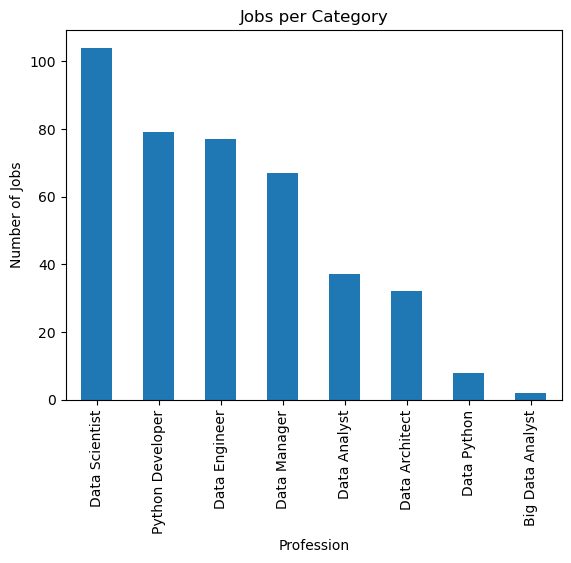

In [27]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt


headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36"
}


# keywords
professions = [
    "Data Scientist",
    "Data Analyst",
    "Python Developer",
    "Data Engineer",
    "Data Manager",
    "Data Architect",
    "Big Data Analyst",
    "Data Python"
]


df = pd.DataFrame(columns=[
    "profession",
    "title",
    "link",
    "company",
    "location"
])

session = requests.Session()


for profession in professions:

    query = profession.lower().replace(" ", "%20")

    for page_num in range(1, 6):  # مثلا 5 صفحه اول

        url = f"https://www.jobs.ch/en/vacancies/?page={page_num}&term={query}"

        response = session.get(url, headers=headers, timeout=10)

        soup = BeautifulSoup(response.text, "html.parser")

        job_ads = soup.find_all("a", {"data-cy": "job-link"})

        print(f"{profession} page {page_num} -> {len(job_ads)} jobs")

        for job in job_ads:

            try:
                title = job.get("title")
            except:
                title = None

            try:
                link = "https://www.jobs.ch" + job.get("href")
            except:
                link = None

            parent = job.find_parent()

            try:
                company = parent.find("span").get_text(strip=True)
            except:
                company = None

            try:
                location = parent.find_all("p")[1].get_text(strip=True)
            except:
                location = None

            df = pd.concat([
                df,
                pd.DataFrame([{
                    "profession": profession,
                    "title": title,
                    "link": link,
                    "company": company,
                    "location": location
                }])
            ], ignore_index=True)
# remove duplicates
df = df.drop_duplicates(subset=["title", "company"])

# save csv
df.to_csv("jobs.csv", index=False)

# show result
print(df.head())
print("\nTotal jobs:", len(df))

df["profession"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Jobs per Category"
)

plt.xlabel(
    "Profession"
)

plt.ylabel(
    "Number of Jobs"
)

plt.show()